In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


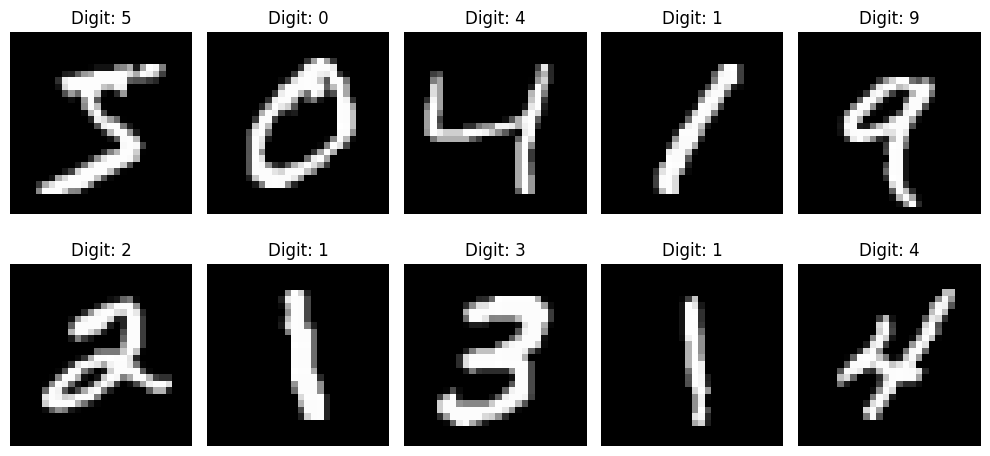

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    
    plt.subplot(2,5,i+1)
    
    plt.imshow(
        X_train[i],
        cmap='gray'
    )
    
    plt.title(f"Digit: {y_train[i]}")
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [6]:
X_train = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_test = X_test.reshape(
    -1,
    28,
    28,
    1
)

In [7]:
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [21]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

c:\Users\Puneeth Ram\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    
    patience=2,
    
    restore_best_weights=True
)

In [24]:
history = model.fit(
    X_train,
    y_train,
    
    epochs=5,
    
    batch_size=32,
    
    validation_split=0.2,
    
    callbacks=[early_stop]
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9314 - loss: 0.2283 - val_accuracy: 0.9829 - val_loss: 0.0617
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.9739 - loss: 0.0858 - val_accuracy: 0.9858 - val_loss: 0.0493
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9812 - loss: 0.0619 - val_accuracy: 0.9880 - val_loss: 0.0421
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9854 - loss: 0.0482 - val_accuracy: 0.9865 - val_loss: 0.0460
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.9878 - loss: 0.0403 - val_accuracy: 0.9889 - val_loss: 0.0399


In [25]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9896 - loss: 0.0318
Test Accuracy: 0.9896000027656555


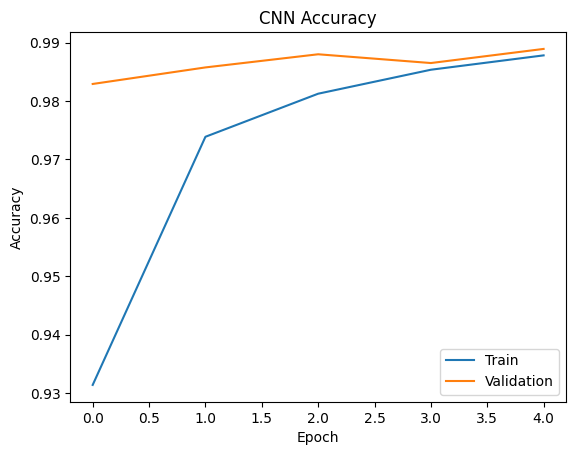

In [26]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

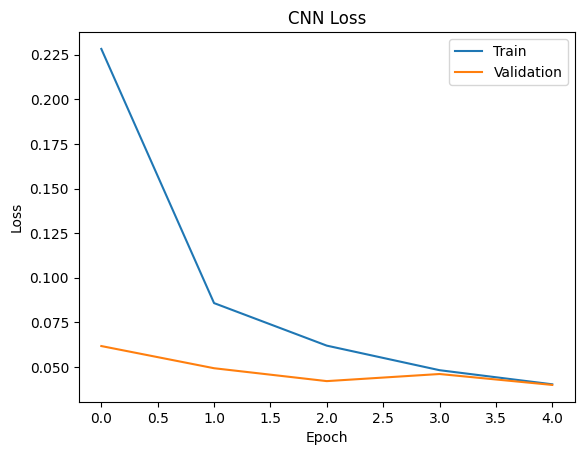

In [27]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [28]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [29]:
predicted_digit = np.argmax(predictions[0])

print("Predicted Digit:", predicted_digit)

Predicted Digit: 7


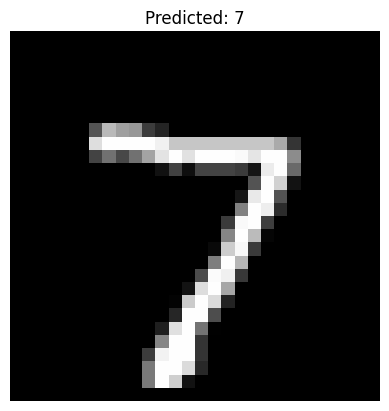

In [30]:
plt.imshow(
    X_test[0].reshape(28,28),
    cmap='gray'
)

plt.title(f"Predicted: {predicted_digit}")

plt.axis('off')

plt.show()

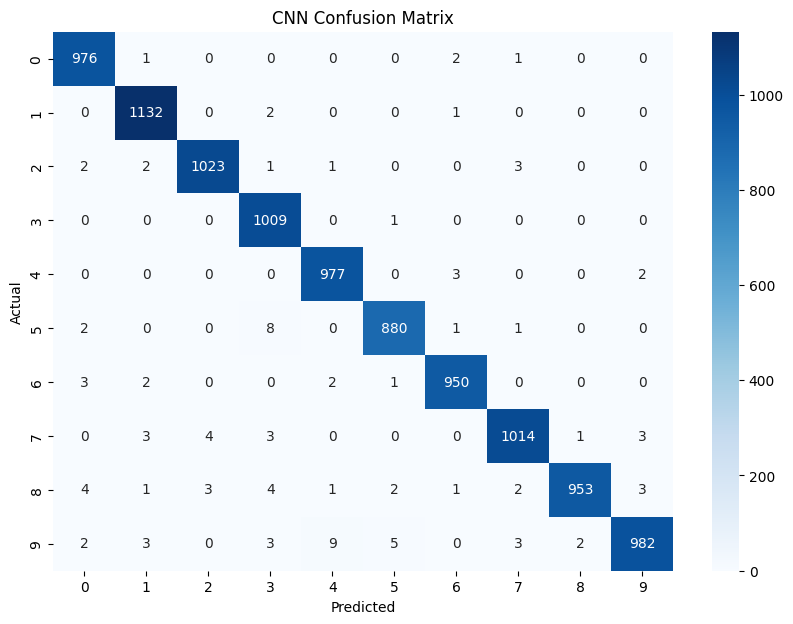

In [31]:
y_pred = np.argmax(predictions, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("CNN Confusion Matrix")

plt.show()

In [32]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [33]:
model.save(
    "models/cnn_digit_classifier.h5"
)